# DeepDetect Audio Deepfake Detection Challenge - Summary Notebook

Created by: Ardacandra Subiantoro

Note: this notebook is only report summary for this project. The complete source code can be accessed in this link : https://github.com/Ardacandra/deepdetect_audio_deepfake_detection_challenge

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
from collections import Counter, defaultdict
import math
import random
from glob import glob
import librosa
from pydub import AudioSegment
from IPython.display import Audio

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier, Pool

import torch
import torchaudio
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from transformers import Wav2Vec2Processor, Wav2Vec2Model

sns.set_style(style="whitegrid")

In [2]:
#set config
DATA_PATH = "data/deep-detect/dataset/"
OUTPUT_PATH = "output/"
PREDS_PATH = "output/preds/"
MODELS_PATH = "models/"

## 1. Introduction

With the rapid advancement of generative AI technologies, distinguishing between authentic and synthetic voices has become increasingly challenging. Although voice generation and cloning offer valuable applications—such as improving accessibility and personalization—they also introduce significant risks, including misinformation, fraud, and identity misuse.

This goal of this competition is to develop models capable of determining whether an audio recording is genuine or AI-generated. The broader aim is to advance AI safety research and contribute to the development of reliable techniques for detecting audio deepfakes in real-world scenarios.

This notebook contains the result of my exploration and experiments to address this audio deepfake detection problem.

**Table of Contents:**
1. Exploratory Data Analysis (EDA) 
2. ML-based feature engineering
3. Benchmark ML models (CatBoost, XGBoost, etc.)
4. Deep Learning feature extraction (wav2vec2)
5. State-of-the-Art (SOTA) modeling
6. Model prediction evaluation and analysis

## 2. Data Overview

Checking dataset splits

In [3]:
def get_subfolders(path):
    subfolders = []
    for root, dirs, _ in os.walk(path):
        for d in dirs:
            subfolders.append(os.path.relpath(os.path.join(root, d), path))
    return sorted(subfolders)

def get_file_stats(folder_path):
    file_prefixes = []
    file_extensions = []
    file_count = 0

    for root, _, files in os.walk(folder_path):
        for f in files:
            file_count += 1

            name, ext = os.path.splitext(f)
            prefix = ''.join(ch for ch in name if not ch.isdigit())
            ext = ext.lower().lstrip(".")

            file_prefixes.append(prefix if prefix else "NO_PREFIX")
            file_extensions.append(ext if ext else "NO_EXT")


    return file_count, Counter(file_prefixes), Counter(file_extensions)

In [4]:
folders_list = get_subfolders(DATA_PATH)

for folder in folders_list:
    path = os.path.join(DATA_PATH, folder)
    if not os.path.isdir(path):
        print(f"⚠️  Folder not found: {folder}")
        continue

    count, prefix_counter, ext_counter = get_file_stats(path)

    print(f"\n📂 Folder: {folder}. Total files: {count}.")
    prefix_str = [f"{num} x {prefix}" for prefix, num in prefix_counter.items()]
    print(f"Prefixes : {', '.join(prefix_str)}")
    ext_str = [f"{num} x {ext}" for ext, num in ext_counter.items()]
    print(f"Extensions : {', '.join(ext_str)}")


📂 Folder: holdout. Total files: 14397.
Prefixes : 14397 x audio_
Extensions : 14397 x wav

📂 Folder: testing. Total files: 11710.
Prefixes : 4634 x file, 6355 x itw, 243 x train_ami_isc_h_mie__, 85 x dev_ami_isb_h_mio__, 123 x dev_ami_isb_h_fie__, 141 x eval_ami_isb_h_fio__, 58 x eval_ami_isb_sdm_fie__, 46 x dev_ami_isb_h_mie__, 25 x train_ami_isc_h_mio__
Extensions : 11710 x wav

📂 Folder: testing/fake. Total files: 4733.
Prefixes : 2370 x file, 2363 x itw
Extensions : 4733 x wav

📂 Folder: testing/real. Total files: 6977.
Prefixes : 2264 x file, 3992 x itw, 243 x train_ami_isc_h_mie__, 85 x dev_ami_isb_h_mio__, 123 x dev_ami_isb_h_fie__, 141 x eval_ami_isb_h_fio__, 58 x eval_ami_isb_sdm_fie__, 46 x dev_ami_isb_h_mie__, 25 x train_ami_isc_h_mio__
Extensions : 6977 x wav

📂 Folder: training. Total files: 76943.
Prefixes : 53882 x file, 22245 x itw, 244 x dev_ami_ib_h_mio__, 309 x dev_ami_ib_sdm_mio__, 195 x dev_ami_ib_h_fie__, 68 x dev_ami_ib_h_fio__
Extensions : 23678 x mp3, 53265 x 

**Key Takeaways**

- Training set: 76.9k audio files — 54.2% real, 45.8% fake.
- File formats: All real samples are .wav, while fake samples are 67.2% .mp3 and 32.8% .wav.
- Note: Feature extraction must avoid bias due to format differences.
- Testing set: 11.7k audio files — 59.6% real, 40.4% fake, all .wav.
- Holdout set: 14.4k audio files, all .wav.
- File origins: Prefixes like file, itw, and train/dev_ami suggest multiple source datasets.

| Split        | Total Files | Real (%) | Fake (%) | File Types (Real)              | File Types (Fake)          | Notes                           |
| ------------ | ----------- | -------- | -------- | ------------------------------ | -------------------------- | ------------------------------- |
| **Training** | 76.9k       | 54.2%    | 45.8%    | 100% `.wav`                    | 67.2% `.mp3`, 32.8% `.wav` | Watch for format bias           |
| **Testing**  | 11.7k       | 59.6%    | 40.4%    | 100% `.wav`                    | 100% `.wav`                | No `.mp3` files                 |
| **Holdout**  | 14.4k       | —        | —        | 100% `.wav`                    | —                          | Labels withheld                 |


Show a few audio samples

Loaded data/deep-detect/dataset/training/real/dev_ami_ib4001_h01_fie038_0000919_0001249.wav
Sample rate: 16000
Duration: 3.30 seconds
Shape of waveform: (52800,)


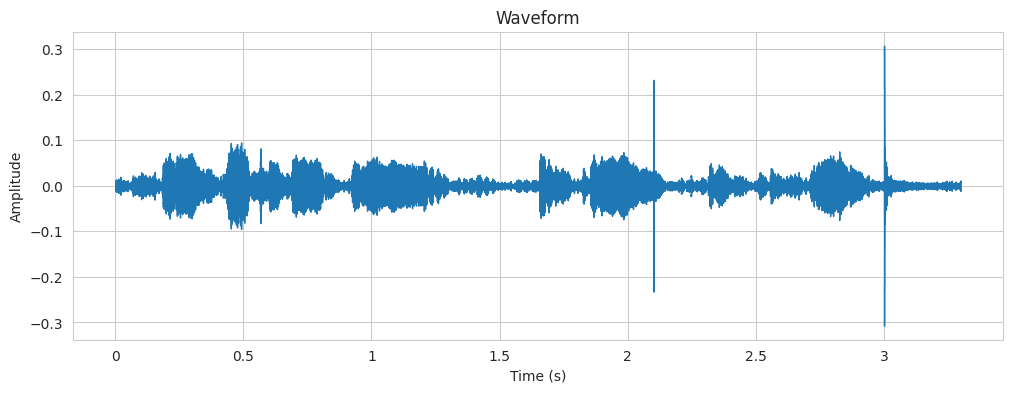

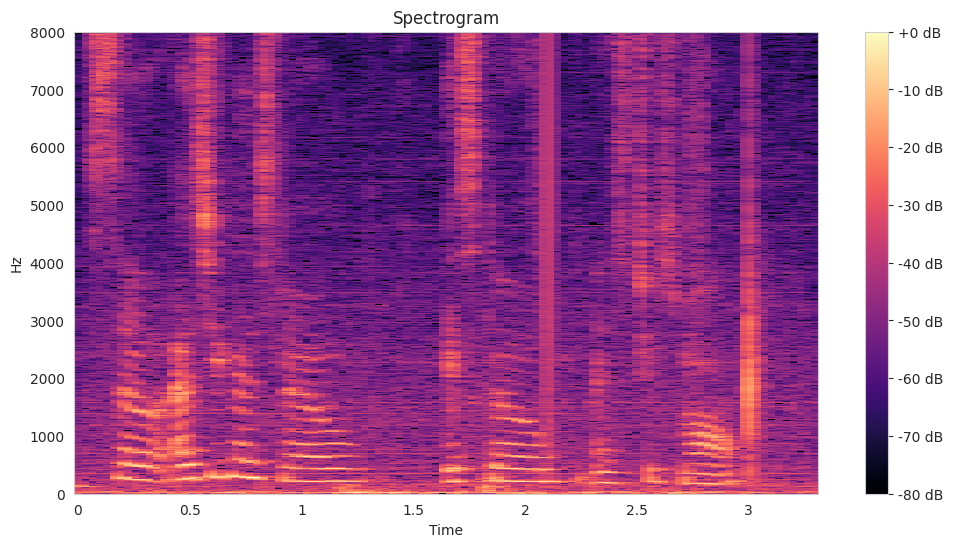

Channels: 1
Frame rate: 16000
Sample width: 4
Length (ms): 3300
Loaded data/deep-detect/dataset/training/fake/file3.mp3
Sample rate: 22050
Duration: 1.59 seconds
Shape of waveform: (35136,)


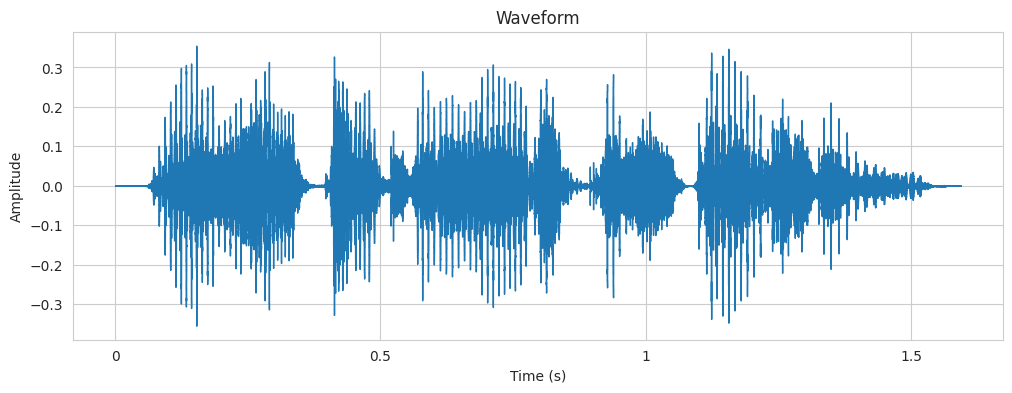

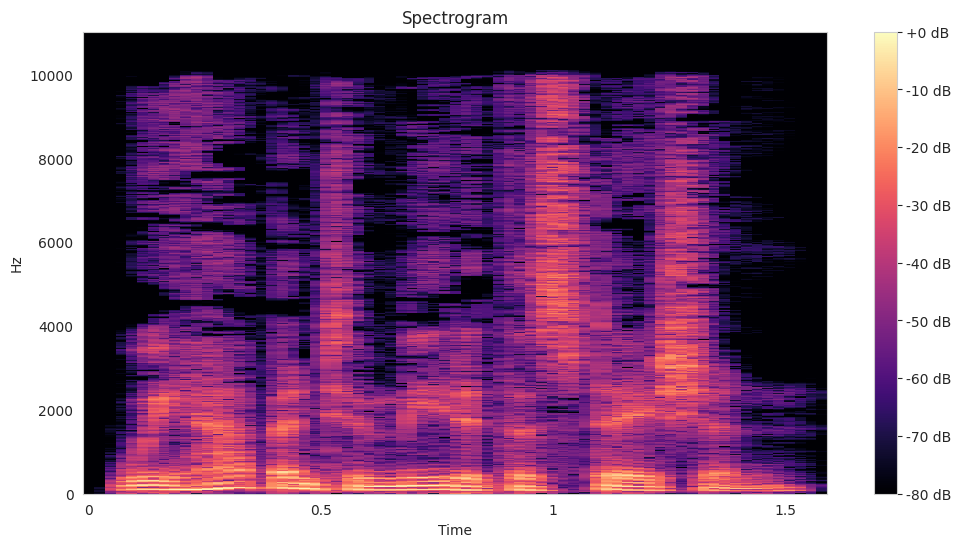

Channels: 1
Frame rate: 22050
Sample width: 2
Length (ms): 1593


In [5]:
sample_wav = os.path.join(DATA_PATH, "training/real/dev_ami_ib4001_h01_fie038_0000919_0001249.wav")
sample_mp3 = os.path.join(DATA_PATH, "training/fake/file3.mp3")
audio_samples = [sample_wav, sample_mp3]

for sample in audio_samples:
    # ---------- LOAD AUDIO ----------
    print('='*100)
    y, sr = librosa.load(sample, sr=None)  # waveform and sample rate
    print(f"Loaded {sample}")
    print(f"Sample rate: {sr}")
    print(f"Duration: {len(y)/sr:.2f} seconds")
    print(f"Shape of waveform: {y.shape}")

    # ---------- VISUALIZE WAVEFORM ----------
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(y, sr=sr)
    plt.title("Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.show()

    # ---------- SPECTROGRAM ----------
    D = np.abs(librosa.stft(y))
    DB = librosa.amplitude_to_db(D, ref=np.max)

    plt.figure(figsize=(12, 6))
    librosa.display.specshow(DB, sr=sr, x_axis="time", y_axis="hz")
    plt.colorbar(format="%+2.0f dB")
    plt.title("Spectrogram")
    plt.show()

    # ---------- METADATA (with pydub) ----------
    audio = AudioSegment.from_file(sample)
    print(f"Channels: {audio.channels}")
    print(f"Frame rate: {audio.frame_rate}")
    print(f"Sample width: {audio.sample_width}")
    print(f"Length (ms): {len(audio)}")

In [6]:
# ---------- PLAY AUDIO ----------
Audio(sample_wav)  # plays the file

In [7]:
# ---------- PLAY AUDIO ----------
Audio(sample_mp3)  # plays the file

**Key Takeaways**
- Audio samples seem to consist of a few seconds of spoken words

## 3.  Exploratory Data Analysis

- Focus on insights instead of raw plots.

- Compare waveform / spectrogram patterns of real vs. fake.

- Highlight statistical differences (mean RMS energy, zero-crossing rate, etc.).

- Show correlations between features if applicable.

Example: “Fake audios tend to have smoother spectral envelopes and shorter durations.”

## 4. ML Feature Engineering

- Describe how you extracted hand-crafted features (e.g., MFCCs, spectral stats, zero-crossing rate, duration).

- Summarize your feature selection or dimensionality reduction (e.g., PCA, mutual info).

- Show feature importance chart from a baseline model (e.g., CatBoost).

## 5. ML Benchmark Models

- Compare multiple models: Logistic Regression, RandomForest, CatBoost, etc.

Include table:

Model	Features	F1-score (Val)	Accuracy	Notes
CatBoost	Engineered	0.87	0.88	Best ML baseline

- Show binary separation plot (distribution of predicted probabilities).

- Optional: confusion matrix of the best ML model.

## 6. Deep Learning Feature Engineering

- Describe the embeddings used (e.g., wav2vec2, HuBERT, Audio Spectrogram Transformer).

- Mention how embeddings were extracted and stored for reproducibility.

- Add t-SNE or UMAP visualization to show cluster separability.

Tip: briefly justify why the chosen embedding makes sense for your task.

## 7. Deep Learning Modeling

- Summarize architectures tried (MLP, CNN, Transformer, attention-based).

- Include model diagram (optional) and key hyperparameters.

- Training setup (optimizer, scheduler, batch size, early stopping, etc.).

- Plot training curves (loss, F1 over epochs).

- Report best model metrics

## 8. SOTA Modeling

- Describe your top-performing setup (e.g., fine-tuned transformer or ensemble).

- Explain ensemble method (averaging, stacking, voting).

- Show performance improvement.

## 9. Model Analysis & Interpretability

- Confusion matrix and sample inspection.

- Examples of false positives / false negatives (waveform + spectrogram).

- Feature importance or SHAP analysis (for ML models).

- Embedding visualization of model outputs.

## 10. Final Results and Discussion

- Summarize your leaderboard scores.

- Discuss what worked best and what didn’t.

- Mention computational trade-offs (inference time, model size).

- Suggest future improvements.

## 11. Conclusion